# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` está establecida como tipo de dato float64, por lo que será necesario cambiarla a formato int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
num_cols = df[['edad','nivel_ingreso','visitas_mes','compras_mes',
               'gasto_publicidad_dirigida','satisfaccion','ingreso_anual']]

num_cols.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


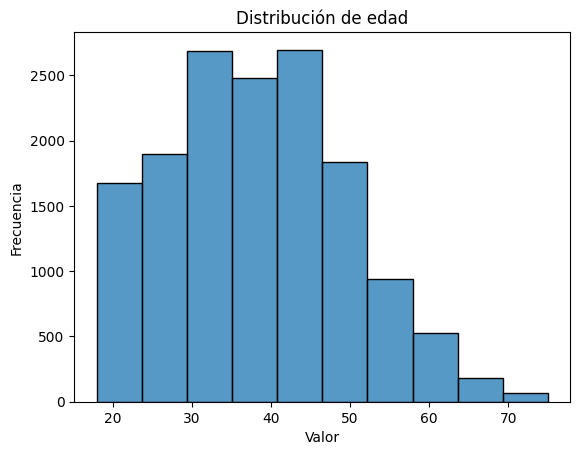

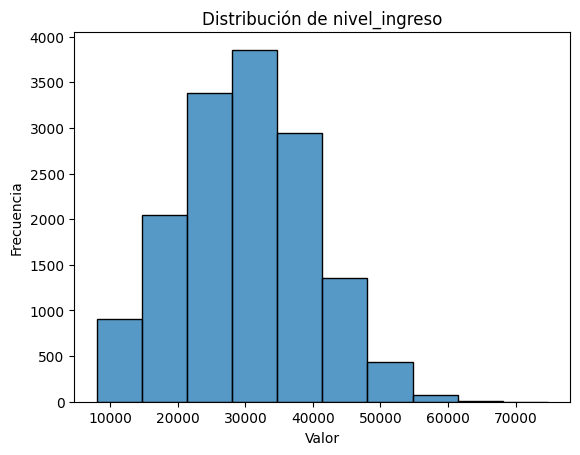

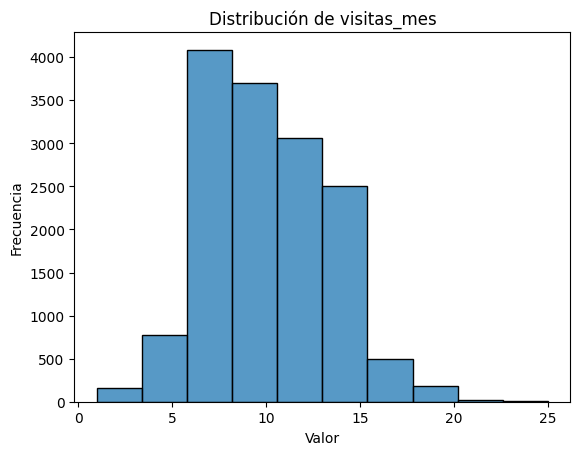

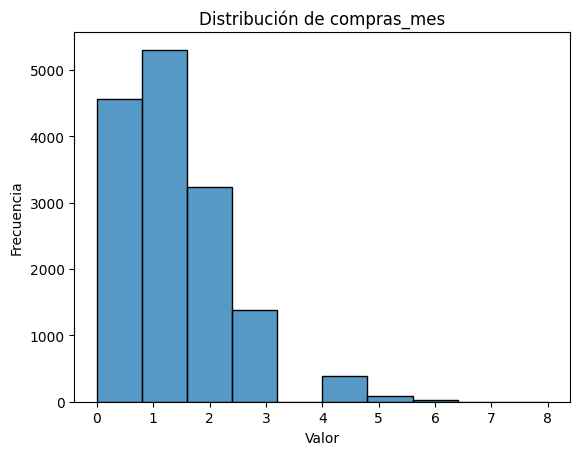

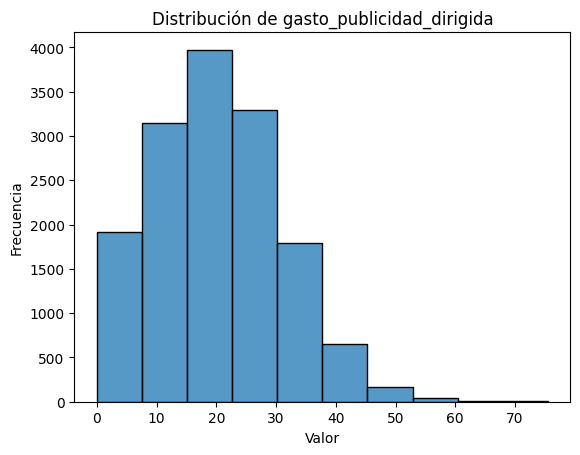

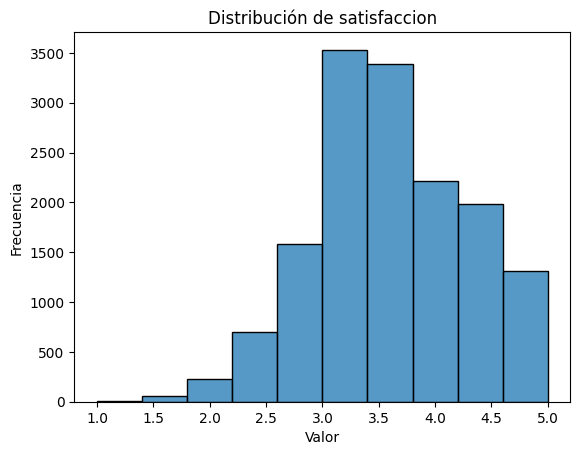

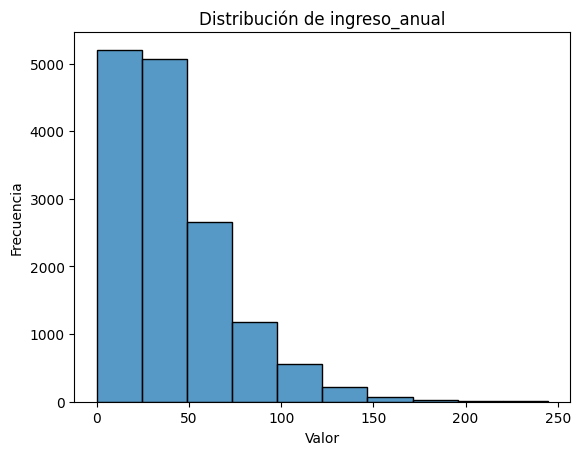

In [7]:
#Histogramas para visualizar distribución
for col in num_cols:
    sns.histplot(df[col],bins=10)
    plt.title(f'Distribución de {col}')
    plt.ylabel('Frecuencia')
    plt.xlabel('Valor')
    plt.show()

✍️ **Comentario**:

Diagnóstico inicial de variables numéricas

- `edad` — Se observa que la edad de los clientes mantiene un promedio de 38 años, y por el resultado de la media parece no existir sesgo, pero al observar el histograma, se aprecia un sesgo a la derecha. Puede deberse a que las personas mayores suelen ser menos probables a comprar en línea.
- `nivel_ingreso` — En nivel de ingreso se observa un promedio de 30 mil, el cual coincide con el dato de la media, pero nuevamente al observar el gráfico se observa un sesgo a la derecha.
- `visitas_mes` — El promedio de las visitas por mes es de 10, coincidiendo con la mediana, aunque se aprecia una cola pesada hacia la derecha.
- `compras_mes` — En esta columna se muestra un promedio de 1.2 frente a una mediana de 1, lo cual destapa la presencia de un sesgo a la derecha que al revisar el histograma es bastante notorio.
- `gasto_publicidad_dirigida` — En cuanto al gasto publicitario, se encuentra que el promedio es mayor a la media, por lo que existe un sesgo a la derecha que se confirma al observar el gráfico.
- `satisfaccion` — La satisfacción del cliente muestra un promedio y mediana de 3.6, lo cual apunta a una distribución uniforme. Sin embargo el gráfico señala un sesgo a la izquierda, producto de una mayor proporción de calificaciones altas.
- `ingreso_anual` — El promedio de ingreso registra un 36.59 frente a una medianaa de 30.70, por lo que se percibe un sesgo a la derecha que el histograma de distribución confirma.

#### Explorar variables binarias

In [8]:
# Verificar que cada columna tenga únicamente dos valores posibles
bin_cols = df[['miembro_premium','abandono']]

for col in bin_cols:
    print(f'Valores en la columna {col}')
    print(df[col].value_counts())
    print('')

Valores en la columna miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64

Valores en la columna abandono
0    12739
1     2261
Name: abandono, dtype: int64



✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — No se muestran valores anómalos ni no válidos
- `abandono` — No se muestran valores anómalos ni no válidos

#### Explorar variables categóricas

In [9]:
# Verificar el número de valores únicos por variable categórica
cat_cols = df[['tipo_dispositivo','region']]

for col in cat_cols:
    print(f'Valores en la columna {col}')
    print(df[col].value_counts())
    print('')

Valores en la columna tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Valores en la columna region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64



In [10]:
# Explorar variables categóricas y cómo se distribuyen
for col in cat_cols:
    print(f'Proporción de valores en la columna {col}')
    print(df[col].value_counts(normalize=True))
    print('')

Proporción de valores en la columna tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

Proporción de valores en la columna region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64



✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — No se muestran valores no válidos en la columna. La gran mayoría de usuarios acceden a la plataforma por móvil, seguido de la plataforma de escritorio y una proporción bastante baja de acceso por tabletas.
- `region` — No hay presencia de valores no válidos. Se muestra una proporción bastante equitativa entre regiones, con la zona norte como la más numerosa y la zona este con apenas un 20%.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

In [11]:
# Visualizar la matriz de correlación para identificar relaciones
matriz = df.corr()
matriz.style.background_gradient(cmap='PuBu')

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.004605,-0.011500,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,-0.005598,0.005870,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,-0.012657,-0.008943,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.003431,0.008291,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.002721,-0.004586,0.197483
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.025734,-0.023833,0.056171
miembro_premium,0.004605,-0.005598,-0.012657,0.003431,0.002721,0.025734,1.000000,-0.120488,0.093099
abandono,-0.011500,0.005870,-0.008943,0.008291,-0.004586,-0.023833,-0.120488,1.000000,-0.002824
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,0.093099,-0.002824,1.000000


✍️ **Comentario**: 

Observaciones generales (Heatmap)  
- Se observa que la mayoría de pares en el dataset muestran una correlación casi nula. Sin embargo hay ciertas relaciones que parecen interesantes a primera vista, tales como `gasto_publicidad_dirigida` con `compras_mes`, `gasto_publicidad_dirigida` con `ingreso_anual`, `visitas_mes` con `compras_mes` y `visitas_mes` con `ingreso_anual` que llevan una relación positiva débil; `gasto_publicidad_dirigida` con `visitas_mes` que poseen una relación positiva moderada; y `compras_mes` con `ingreso_anual` con una relación positiva fuerte.


Observaciones respecto a `ingreso_anual`  
- `ingreso_anual` muestra una correlación positiva con las variables `gasto_publicidad_dirigida`, `visitas_mes` y `compras_mes`. Las columnas `gasto_publicidad_dirigida` y `visitas_mes` tienen una relación con el ingreso que puede ser objeto de análisis, sobretodo `gasto_publicidad_dirigida`, ya que esta misma muestra a su ves indicios de correlación con las visitas del cliente al sitio. `compras_mes` debe ser analizada más a detalle por peligro de colinealidad.


### Scatterplot general

Con base en los resultados del análisis de correlación, se identificaron las columnas `visitas_mes`,`compras_mes`,`gasto_publicidad_dirigido` e `ingreso_anual` como aquellas que poseen una correlación interesante entre si, por lo que se decidió generar un scatterplot general utilizando unicamente estas cuatro columnas.

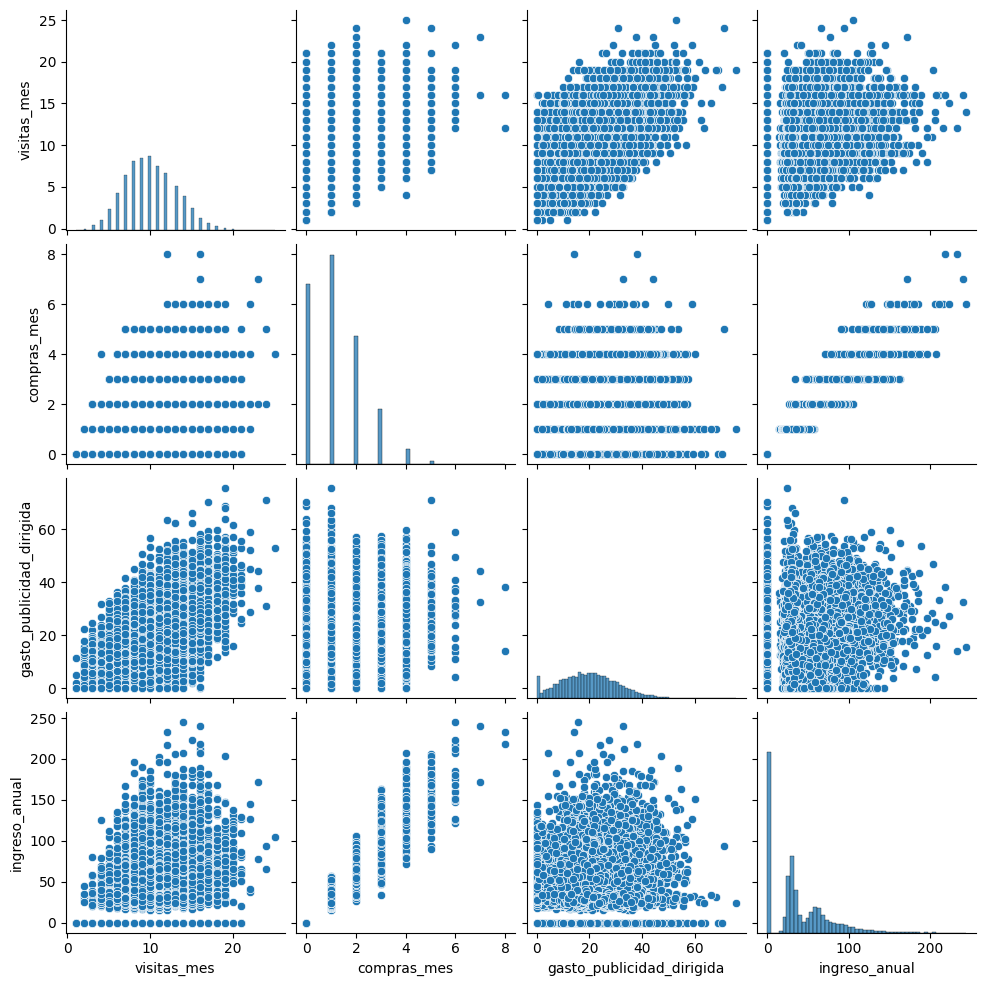

In [12]:
scatter_cols = df[['visitas_mes','compras_mes','gasto_publicidad_dirigida',
                   'ingreso_anual']]

sns.pairplot(scatter_cols)

### Scatterplot para pares clave

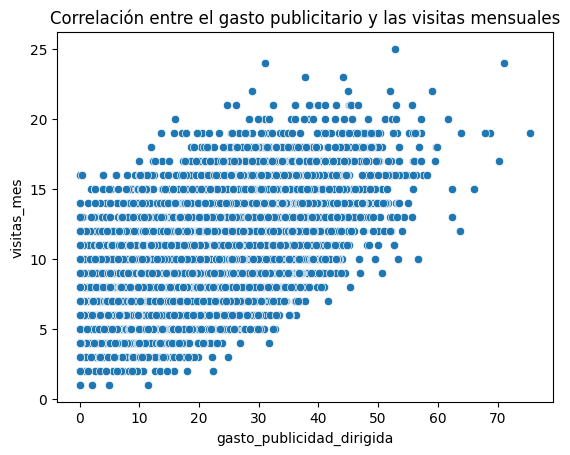

In [13]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x='gasto_publicidad_dirigida',y='visitas_mes')
plt.title('Correlación entre el gasto publicitario y las visitas mensuales')
plt.show()

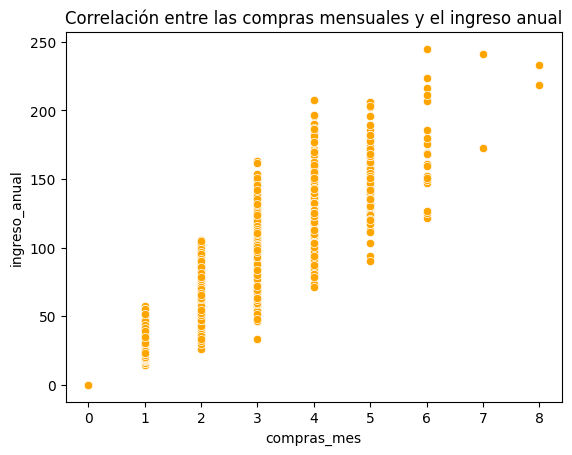

In [14]:
sns.scatterplot(data=df,x='compras_mes',y='ingreso_anual',color='orange')
plt.title('Correlación entre las compras mensuales y el ingreso anual')
plt.show()

✍️ **Comentario**:

Observaciones iniciales (Scatterplot)

**gasto_publicidad_dirigido vs visitas_mes**
- Dirección positiva.
- Dispersión alta.
- Sin outliers.

**compras_mes vs ingreso_anual**
- Dirección positiva.
- Dispersión media.
- Sin outliers.
- Posible colinealidad.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [15]:
# Calcular correlación entre variables relevantes
pearson_1 = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'],method='pearson')
spearman_1 = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'],method='spearman')
print('gasto_publicidad_dirigida vs visitas_mes')
print('Pearson:', pearson_1)
print('Spearman:', spearman_1)

gasto_publicidad_dirigida vs visitas_mes
Pearson: 0.5789472719412827
Spearman: 0.5592673242622609


In [16]:
# Calcular correlación entre variables relevantes
pearson_2 = df['compras_mes'].corr(df['ingreso_anual'],method='pearson')
spearman_2 = df['compras_mes'].corr(df['ingreso_anual'],method='spearman')
print('compras_mes vs ingreso_anual')
print('Pearson:', pearson_2)
print('Spearman:', spearman_2)

compras_mes vs ingreso_anual
Pearson: 0.9671485435708564
Spearman: 0.967482492032673


✍️ **Comentario**: 

Observaciones de correlación

**gasto_publicidad_dirigido vs visitas_mes**
- Dirección positiva.
- Magnitud moderada.

**compras_mes vs ingreso_anual**
- Dirección positiva.
- Magnitud alta.
- Posible colinealidad.

**Decisión para el análisis**
Debido al alto coeficiente de correlación entre las columnas `compras_mes` e `ingreso_anual` y su relación estrecha (compras * precio promedio = ingreso), se detecta colinelidad en este par de variables, por lo que sería redundante considerar esta correlación para responder al objetivo del análisis.

Es por ello que se ha decidido sumar al análisis el par de variables `visitas_mes` con `ingreso_anual`, ya que si bien mantienen una correlación baja, este par tiene conexión con la relación entre las columnas `gasto_publicidad_dirigido` y `visitas_mes`, cuya correlación es positiva moderada. De esta forma se busca encontrar correlación entre variables (sin buscar causalidad) que nos ayude a desarrollar conclusiones.

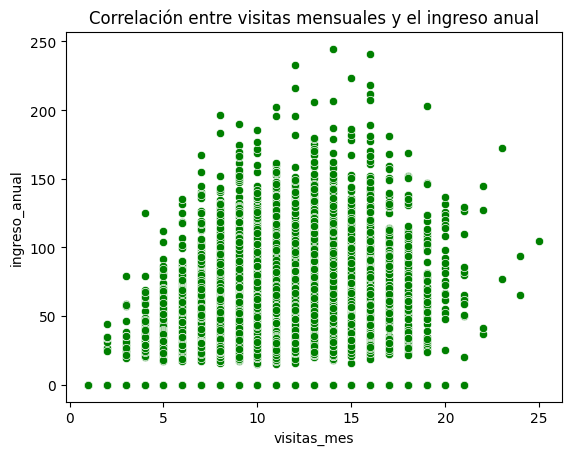

In [17]:
#Scatterplot de nuevo par de variables
sns.scatterplot(data=df,x='visitas_mes',y='ingreso_anual',color='green')
plt.title('Correlación entre visitas mensuales y el ingreso anual')
plt.show()

In [18]:
#Coeficientes de nuevo par de variables
pearson_3 = df['visitas_mes'].corr(df['ingreso_anual'],method='pearson')
spearman_3 = df['visitas_mes'].corr(df['ingreso_anual'],method='spearman')
print('visitas_mes vs ingreso_anual')
print('Pearson:', pearson_3)
print('Spearman:', spearman_3)

visitas_mes vs ingreso_anual
Pearson: 0.3371466432498745
Spearman: 0.32095369737696483


✍️ **Comentario**: 

Observaciones de correlación

**gasto_publicidad_dirigido vs visitas_mes**
- Dirección positiva.
- Magnitud baja.

### Punto-biserial

In [19]:
# Calcular correlación entre variables relevantes
print('miembro_premium vs ingreso_anual:')
pointbiserialr(df['miembro_premium'],df['ingreso_anual'])

miembro_premium vs ingreso_anual:


SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [20]:
print('abandono vs ingreso_anual:')
pointbiserialr(df['abandono'],df['ingreso_anual'])

abandono vs ingreso_anual:


SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación positiva con una magnitud muy baja.

**abandono vs ingreso_anual**
- Relación positiva, pero casi inexistente.

### V de Cramér

In [21]:
# Función para calcular V de Cramér
def cramers_v(df,col_1,col_2):
    tabla = pd.crosstab(df[col_1],df[col_2])
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape)-1)))

    return f'V de Cramér: {v:3f}'

In [22]:
# Aplicar V de Cramér en variables relevantes
cramers_v(df,'abandono','miembro_premium')

'V de Cramér: 0.120219'

✍️ **Comentario**: 

Observaciones V de Cramér

El resultado del coeficiente de correlación señala una relación positiva débil entre las variables.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Existe evidencia de correlación positiva entre el gasto publicitario y las visitas mensuales al sitio web

**Evidencia visual:**

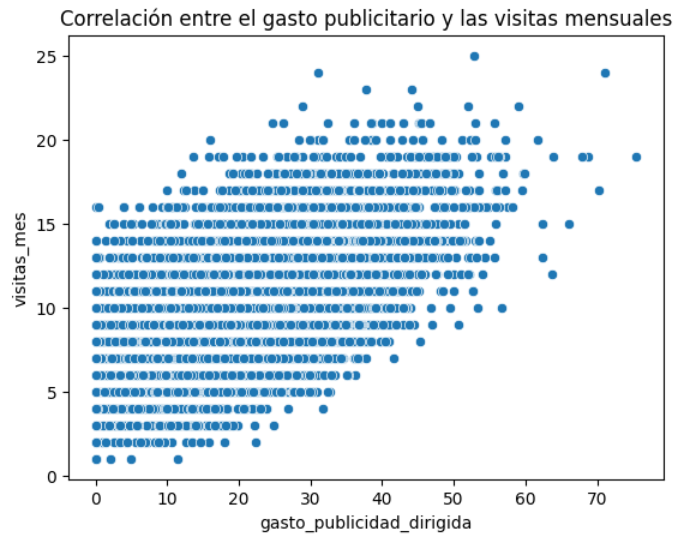

**Evidencia numérica:** 
- Pearson: 0.5789472719412827
- Spearman: 0.5592673242622609

**Interpretación**  
Ambos coeficientes muestran la presencia de una correlación positiva lineal y constante entre las columnas.

**No podemos afirmar**  
No existe evidencia estadística para afirmar que existe causalidad entre variables.

**Implicación de negocio**  
La relación es moderada, por lo que vale la pena analizar más a detalle la relación entre el gasto publicitario y las visitas al sitio web, ya que como veremos posteriormente, las visitas tienen relación con el ingreso anual.

### Hallazgo 2 — Existe evidencia de correlación positiva entre las visitas mensuales al sitio web y los ingresos anuales

**Evidencia visual:** 

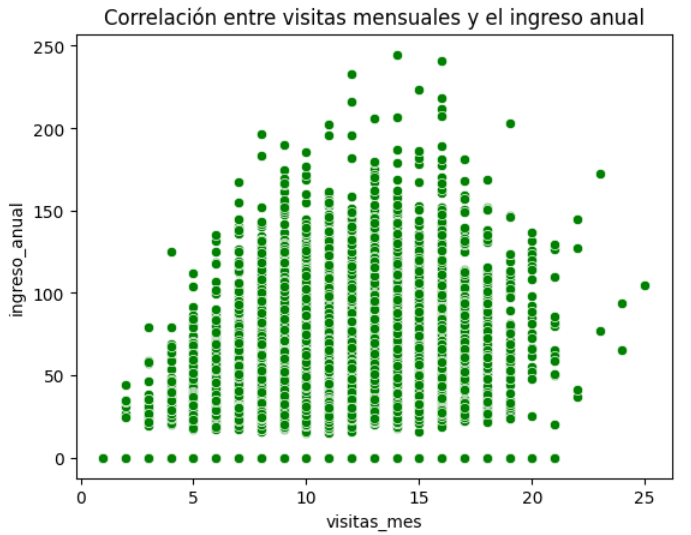

**Evidencia numérica:** 
- Coeficiente Pearson: 0.33714
- Coeficiente Spearman: 0.32095

**Interpretación**  
Ambos coeficientes muestran la presencia de una correlación positiva lineal y constante entre las columnas.

**No podemos afirmar**  
No existe evidencia estadística para afirmar que existe causalidad entre variables.

**Implicación de negocio**  
La relación entre las variables es débil, pero existe, por lo que se pueden encontrar oportunidades si se analiza más a fondo, ya por por el momento, no existe evidencia estadística para afirmar causalidad.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad

### **Próximos pasos** 

- Probar segmentación adicional
  - Segmentar nivel de ingreso para determinar si la relación positiva en las variables esta ligada a dicho elemento.
  - Segmentar por edad, ya que el sesgo mostrado en el histograma señala un diferencia en la adopción de la tecnología y de la experiencia de compra en línea entre personas jóvenes y los adultos mayores.

- Análisis por cohortes
  - Analizar el funnel en búsqueda de una oportunidad de mejoría en la experiencia del usuario.